# 第8章 シミュレーション・WebAPIの利用

 * 左上の「ファイル」を開いて、「ドライブにコピーを保存」をしてください。
 * 自分のGoogleドライブに、そのファイルが保存されます。ファイル名は「のコピー」が、最後（右端）についています。それを利用して学習・演習を進めて下さい。

# 8.3 WebAPIの利用 気象庁

WebAPIとは、web経由でアクセスできるサーバの機能を使って、情報などを取り出すプログラム間のやりとりを定めたインタフェースのことである。定まった手順にしたがって要求することにより、自前では持っていない機能を自分のプログラムの中で使うことができ、それを元に簡単なプログラムで、高機能なサービスを提供することができるようになる。

## CSVの利用(1) 気象庁の最高気温データ

気象庁のCSVデータを読み込んで最高気温をプロットするプログラムを作成する。

気象庁 CSV 最高気温

で検索すると、次のページが見つかる。

https://www.data.jma.go.jp/stats/data/mdrr/tem_rct/index_mxtem.html

画面左上の　データ（一覧表）　をクリックする。

このページ内に「気温のCSVダウンロードは、「詳細表示」から行うことができます。」とあるので、詳細表示を見る。

ここに、「CSVファイルでダウンロード」とある。そのURLは、次のものである。

https://www.data.jma.go.jp/stats/data/mdrr/tem_rct/alltable/mxtemsadext00_rct.csv

このURLを利用する。

このプログラムでは、気象庁が毎日更新してサイトに置いている各地の最高気温データを散布図としてプロットする。
* pandasのread_csvを使うことにより、指定したURLのCSVデータをリストdfに読み込む。
* encoding = 'sjis'で、CSVファイルの漢字コードをSJISであると指定する。
* 読み込んだデータの列名（項目名）を指定する。
    * その日の日付がわかる '現在時刻(日)'
    * '観測所番号'
    * その日の日付 + '日の最高気温(℃)'
* その日の日付を取り出して、最高気温の列タイトルを作成する。
    * header_day = str(df['現在時刻(日)'][0]) + "日の最高気温(℃)"
* 最後の行では scatterを使い、x軸に読み込んだ項目の'観測所番号'、y軸に項目 header_day をとり、データをプロットする。


【プログラム8301】

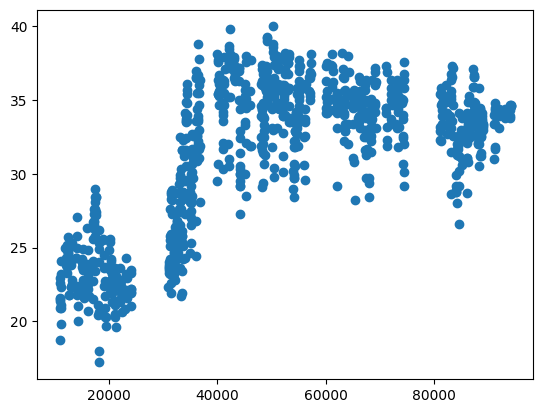

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

the_url = 'https://www.data.jma.go.jp/obd/stats/data/mdrr/tem_rct/alltable/mxtemsadext00_rct.csv'

df = pd.read_csv(
    the_url,
    encoding = 'sjis')

header_day = str(df['現在時刻(日)'][0]) + "日の最高気温(℃)"
plt.scatter(df['観測所番号'], df[header_day])

単純に点を打つのではなく、最高気温を出した時刻の「時」で色を変えることもできる。

【プログラム8302】

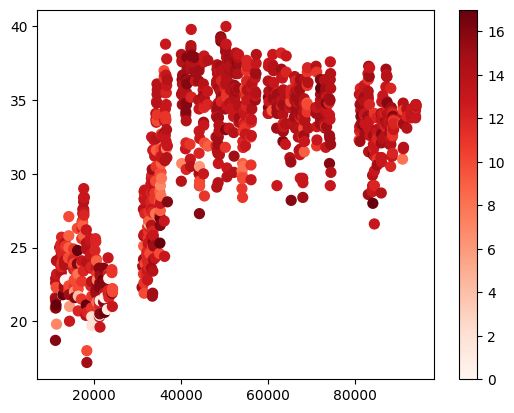

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

the_url = 'https://www.data.jma.go.jp/obd/stats/data/mdrr/tem_rct/alltable/mxtemsadext00_rct.csv'

df = pd.read_csv(
    the_url,
    encoding = 'sjis')

header_day = str(df['現在時刻(日)'][0]) + "日の最高気温(℃)"
header_maxtime = str(df['現在時刻(日)'][0]) + "日の最高気温起時（時）"

plt.scatter(df['観測所番号'], df[header_day],
            s = 50,
            c = df[header_maxtime],
            cmap = 'Reds')
plt.colorbar()

scatterはデータをプロットするマーカーの色の濃淡で表すこともできる。
* s で、マーカーの大きさを指定
* c で、色の濃淡を決める項目 '昨日までの観測史上1位の値（℃）' を指定
* cmap で、濃淡を出すための連続的に色の濃さが変化するカラーマップ 'Reds' を指定。
  * カラーマップの色には，以下のものなどを利用できる。
    * 青ベースの Blues
    * 緑ベースの Greens
* 最後に， colorbar() によってグラフの右側に使っている色の濃淡がわかるカラーバーを表示。

### 確認問題　（確認問題の正答はありません。授業中に提示します）

【問題】上と同様のプロットを気象庁の最低気温のCSVデータを読み込んでプロットしてみよ。

* https://www.data.jma.go.jp/stats/data/mdrr/tem_rct/alltable/mntemsadext00_rct.csv

# 次の教材

8.4 WebAPIの利用 日本銀行
* https://colab.research.google.com/drive/1kp7BEFgtmKG6YRbyFM7B4Q1442O19I-7